# Sweep of `RCP_MU_DECAY_FACTOR`

Effect of the `mu` decay factor on the final packing fraction for a Weibull size distribution (shape 3, scale 1), N = 1000, same seed (same initial configuration) for every run.

`RCP_MU_DECAY_FACTOR` is read by the C++ core through `getenv`, so it is set with `os.environ` before each `pack()` call. The core accepts values in the open interval (0.1, 1.0) and silently falls back to the default (0.85) otherwise, so the sweep starts at 0.1 + 1e-6 instead of exactly 0.1, and `mu_history` is used to check that each value took effect.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from rcpgenerator import Packing

In [2]:
N = 1000
SEED = 123
N_POINTS = 8

# 8 values from 0.1 to 0.95; the core rejects exactly 0.1 (needs > 0.1), so nudge it
factors = np.linspace(0.1, 0.95, N_POINTS)
factors[0] = 0.1 + 1e-6
print(factors)

[0.100001   0.22142857 0.34285714 0.46428571 0.58571429 0.70714286
 0.82857143 0.95      ]


In [3]:
def run_packing(decay_factor):
    """Pack from the same seeded initial configuration with a given RCP_MU_DECAY_FACTOR."""
    os.environ["RCP_MU_DECAY_FACTOR"] = repr(float(decay_factor))
    packing = Packing(
        phi = 0.1,      # Initial particle volume fraction
        N = N,          # Number of particles
        Ndim = 3,       # Number of dimensions
        box = [1.0, 1.0, 1.0],
        walls = [0, 0, 0],   # periodic
        dist = {"type": "weibull", "shape": 3.0, "scale": 1.0},
        neighbor_max = 0,
        seed = SEED,    # same seed -> same initial configuration
    )
    t0 = time.time()
    packing.pack()
    return packing, time.time() - t0

In [4]:
results = []
try:
    for f in factors:
        packing, elapsed = run_packing(f)
        results.append({
            "factor": f,
            "phi_final": packing.phi_final,
            "steps": packing.steps,
            "time": elapsed,
            "mu_history": np.asarray(packing.mu_history),
            "mu_flag_history": np.asarray(packing.mu_flag_history),
        })
        print(f"factor={f:.4f}  phi_final={packing.phi_final:.6f}  steps={packing.steps}  time={elapsed:.1f}s")
finally:
    os.environ.pop("RCP_MU_DECAY_FACTOR", None)   # leave the environment clean

factor=0.1000  phi_final=0.659300  steps=12755  time=1.5s
factor=0.2214  phi_final=0.659310  steps=12675  time=1.5s
factor=0.3429  phi_final=0.659332  steps=12925  time=1.6s
factor=0.4643  phi_final=0.659357  steps=13175  time=1.6s
factor=0.5857  phi_final=0.659400  steps=13425  time=1.7s
factor=0.7071  phi_final=0.659425  steps=14145  time=1.8s
factor=0.8286  phi_final=0.659497  steps=15853  time=2.0s
factor=0.9500  phi_final=0.659777  steps=25234  time=3.3s


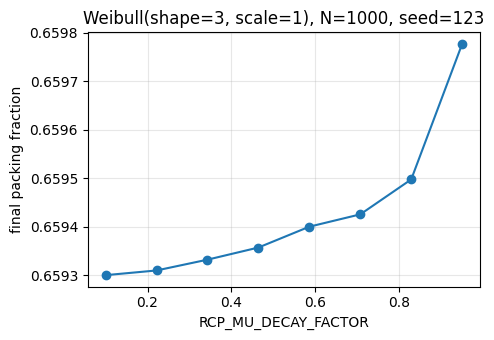

In [5]:
phi_final = np.array([r["phi_final"] for r in results])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(factors, phi_final, "o-")
ax.set_xlabel("RCP_MU_DECAY_FACTOR")
ax.set_ylabel("final packing fraction")
ax.set_title(f"Weibull(shape=3, scale=1), N={N}, seed={SEED}")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Sanity checks

Check that the environment variable had an effect: the per-tick ratio of consecutive distinct `mu` values during the decay should be close to the requested factor, and the number of steps should change with it.

In [6]:
for r in results:
    mu = r["mu_history"]
    changes = mu[1:] / mu[:-1] if len(mu) > 1 else np.array([])
    decays = changes[(changes < 1.0) & (changes > 0.0)]
    # first tick of each decay ladder should equal the requested factor
    med = np.median(decays) if len(decays) else float("nan")
    print(f"requested={r['factor']:.4f}  median observed mu ratio per decay tick={med:.4f}  "
          f"n_ticks={len(decays)}  steps={r['steps']}")

requested=0.1000  median observed mu ratio per decay tick=0.9966  n_ticks=2668  steps=12755
requested=0.2214  median observed mu ratio per decay tick=0.9965  n_ticks=2589  steps=12675
requested=0.3429  median observed mu ratio per decay tick=0.9966  n_ticks=2599  steps=12925
requested=0.4643  median observed mu ratio per decay tick=0.9966  n_ticks=2603  steps=13175
requested=0.5857  median observed mu ratio per decay tick=0.9966  n_ticks=2602  steps=13425
requested=0.7071  median observed mu ratio per decay tick=0.9969  n_ticks=2814  steps=14145
requested=0.8286  median observed mu ratio per decay tick=0.9970  n_ticks=2984  steps=15853
requested=0.9500  median observed mu ratio per decay tick=0.9968  n_ticks=3328  steps=25234


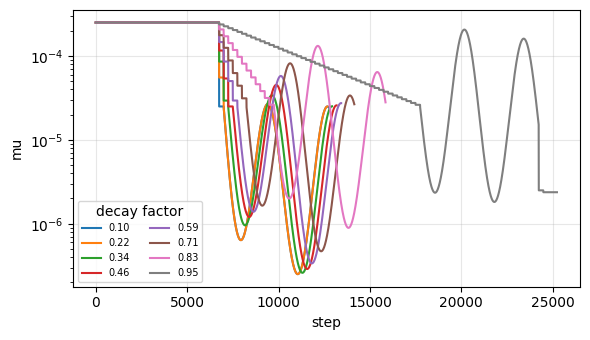

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for r in results:
    ax.semilogy(r["mu_history"], label=f"{r['factor']:.2f}")
ax.set_xlabel("step")
ax.set_ylabel("mu")
ax.legend(title="decay factor", fontsize=7, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()